In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split #divir en base de entrenamiento y prueba
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn import preprocessing
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore") #quitar msj de otras versiones

import os
os.chdir("C:/Users/monts/OneDrive/Escritorio/Ciencia de datos/Módulo 25 (Regresión Logística)/Tarea")

drugs = pd.read_csv("drugs.csv")
drugs.head() #mostrar el encabezado


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [3]:
#Como las variables de Sex, BP y Cholesterol son texto vamos a usar la funcion “preprocessing.LabelEncoder()" para asigar valores
#Creamos la variable
le = preprocessing.LabelEncoder()

#Y comenzamos a codificar las tres columnas
drugs['Sex'] = le.fit_transform(drugs['Sex'])
drugs['BP'] = le.fit_transform(drugs['BP'])
drugs['Cholesterol'] = le.fit_transform(drugs['Cholesterol'])
drugs

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,drugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,drugY
...,...,...,...,...,...,...
195,56,0,1,0,11.567,drugC
196,16,1,1,0,12.006,drugC
197,52,1,2,0,9.894,drugX
198,23,1,2,1,14.020,drugX


In [4]:
#Como ya tenemos nuestra base con valores numéricos procedemos a realizar la división x de las variables predictorias y la y de esta situación
feature_cols = ["Age","Sex","BP","Cholesterol","Na_to_K"]
x = drugs[feature_cols].values #traer sólo los valores numéricos 

#vector de predicción (variable a predecir)
y = drugs.Drug

In [24]:
#Para saber si el fármaco en nacional o extranjero

y_origen = y.map({
    'drugA': 0,
    'drugB': 0,
    'drugC': 0,
    'drugX': 1,
    'drugY': 1
})

In [25]:
#Creación de grupos de entrenamiento y prueba
x_train, x_test, y_origen_train, y_origen_test = train_test_split(x,y_origen, test_size = 0.2, random_state=1)

In [27]:
# Solucionador sag
model = LogisticRegression(solver="sag")
clf_sag = model.fit(x_train, y_origen_train)

y_pred_sag = model.predict(x_test)

print("Intercepto (Beta0): ", clf_sag.intercept_)
print("Pesos (Betas): ", clf_sag.coef_)
print("-------------------------------------------------------------------")
score = model.score(x_test, y_origen_test)
print("Precisión global: ", score)
print("-------------------------------------------------------------------")
print(classification_report(y_origen_test,y_pred_sag,target_names=["Nacional", "Extranjero"]))

Intercepto (Beta0):  [-0.31125584]
Pesos (Betas):  [[-0.03738058 -0.16381094  1.0265336   0.19980899  0.16007449]]
-------------------------------------------------------------------
Precisión global:  0.9
-------------------------------------------------------------------
              precision    recall  f1-score   support

    Nacional       1.00      0.60      0.75        10
  Extranjero       0.88      1.00      0.94        30

    accuracy                           0.90        40
   macro avg       0.94      0.80      0.84        40
weighted avg       0.91      0.90      0.89        40



In [28]:
#Solucionador newton-cg
model = LogisticRegression(solver="newton-cg")
clf_newton = model.fit(x_train, y_origen_train)

y_pred_newton = model.predict(x_test)

print("Intercepto (Beta0): ", clf_newton.intercept_)
print("Pesos (Betas): ", clf_newton.coef_)
print("-------------------------------------------------------------------")
score = model.score(x_test, y_origen_test)
print("Precisión global: ", score)
print("-------------------------------------------------------------------")
print(classification_report(y_origen_test,y_pred_newton,target_names=["Nacional", "Extranjero"]))

Intercepto (Beta0):  [-11.16785361]
Pesos (Betas):  [[0.00667342 0.14894273 3.33862757 2.07461344 0.63861876]]
-------------------------------------------------------------------
Precisión global:  0.975
-------------------------------------------------------------------
              precision    recall  f1-score   support

    Nacional       1.00      0.90      0.95        10
  Extranjero       0.97      1.00      0.98        30

    accuracy                           0.97        40
   macro avg       0.98      0.95      0.97        40
weighted avg       0.98      0.97      0.97        40



In [29]:
#Solucionador liblinear
model = LogisticRegression(solver="liblinear")
clf_liblinear = model.fit(x_train, y_origen_train)

y_pred_liblinear = model.predict(x_test)

print("Intercepto (Beta0): ", clf_liblinear.intercept_)
print("Pesos (Betas): ", clf_liblinear.coef_)
print("-------------------------------------------------------------------")
score = model.score(x_test, y_origen_test)
print("Precisión global: ", score)
print("-------------------------------------------------------------------")
print(classification_report(y_origen_test,y_pred_liblinear,target_names=["Nacional", "Extranjero"]))

Intercepto (Beta0):  [-3.34051275]
Pesos (Betas):  [[-0.02834219 -0.26053256  2.06969328  1.09570978  0.27510142]]
-------------------------------------------------------------------
Precisión global:  0.975
-------------------------------------------------------------------
              precision    recall  f1-score   support

    Nacional       1.00      0.90      0.95        10
  Extranjero       0.97      1.00      0.98        30

    accuracy                           0.97        40
   macro avg       0.98      0.95      0.97        40
weighted avg       0.98      0.97      0.97        40



In [31]:
#Solucionador sga
model = LogisticRegression(solver="saga")
clf_saga = model.fit(x_train, y_origen_train)

y_pred_saga = model.predict(x_test)

print("Intercepto (Beta0): ", clf_saga.intercept_)
print("Pesos (Betas): ", clf_saga.coef_)
print("-------------------------------------------------------------------")
score = model.score(x_test, y_origen_test)
print("Precisión global: ", score)
print("-------------------------------------------------------------------")
print(classification_report(y_origen_test,y_pred_saga,target_names=["Nacional", "Extranjero"]))

Intercepto (Beta0):  [-0.14538838]
Pesos (Betas):  [[-0.03375838 -0.09446989  0.66174876  0.10585855  0.15452535]]
-------------------------------------------------------------------
Precisión global:  0.875
-------------------------------------------------------------------
              precision    recall  f1-score   support

    Nacional       0.86      0.60      0.71        10
  Extranjero       0.88      0.97      0.92        30

    accuracy                           0.88        40
   macro avg       0.87      0.78      0.81        40
weighted avg       0.87      0.88      0.87        40



In [33]:
#Solucionador sga
model = LogisticRegression(solver="lbfgs")
clf_lbfgs = model.fit(x_train, y_origen_train)

y_pred_lbfgs = model.predict(x_test)

print("Intercepto (Beta0): ", clf_lbfgs.intercept_)
print("Pesos (Betas): ", clf_lbfgs.coef_)
print("-------------------------------------------------------------------")
score = model.score(x_test, y_origen_test)
print("Precisión global: ", score)
print("-------------------------------------------------------------------")
print(classification_report(y_origen_test,y_pred_lbfgs,target_names=["Nacional", "Extranjero"]))

Intercepto (Beta0):  [-11.16788199]
Pesos (Betas):  [[0.00667304 0.14894689 3.33863237 2.07461163 0.63862231]]
-------------------------------------------------------------------
Precisión global:  0.975
-------------------------------------------------------------------
              precision    recall  f1-score   support

    Nacional       1.00      0.90      0.95        10
  Extranjero       0.97      1.00      0.98        30

    accuracy                           0.97        40
   macro avg       0.98      0.95      0.97        40
weighted avg       0.98      0.97      0.97        40



In [39]:
# Graficación de la curva ROC y cálculo del área bajo ella
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
# fpr = false positive rate
# tpr = true positive rate
# thresholds = límites para valores de p (si no se definen se toman por dafault 0.5)
y_pred_probs = clf_newton.predict_proba(x_test)[:, 1] # usar sólo la clase positiva (extranjeros) :todos los pacientes y 1 prob de la clase positiva (Extranjero)
fpr, tpr, thresholds = roc_curve(y_origen_test, y_pred_probs)
auc = roc_auc_score(y_origen_test, y_pred_probs)


Text(0.5, 1.0, 'Curva ROC para rgeresión logística')

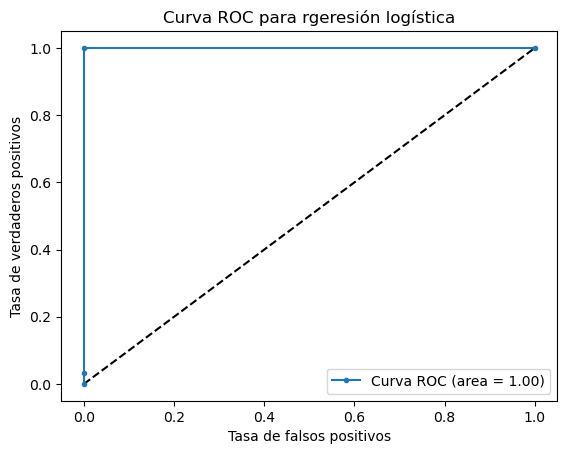

In [41]:
plt.plot([0,1],[0,1], 'k--')
plt.plot(fpr, tpr, marker=".", label = "Curva ROC (area = %0.2f)" % auc)
plt.xlabel("Tasa de falsos positivos") # False positive rate
plt.ylabel("Tasa de verdaderos positivos") # True positive rate
plt.legend(loc = "lower right")
plt.savefig("curva_roc_regresion_logistica.png", dpi=300, bbox_inches="tight")
plt.title("Curva ROC para rgeresión logística")